In [1]:
# pull data from postgres into pandas

from dotenv import load_dotenv
load_dotenv()

import os
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(os.getenv("DATABASE_URL"))

df = pd.read_sql("SELECT * FROM customers_features", engine)
print(f"shape: {df.shape}")
df.head()

shape: (10127, 33)


,churn,customer_age,age_bucket,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,total_trans_ct,avg_spend_per_trans,total_amt_chng_q4_q1,total_ct_chng_q4_q1,trans_count_trend,est_annual_revenue,revenue_percentile,credit_limit_percentile,value_tier,is_premium_card
0,1,45,mature,F,2,College,Married,Less than $40K,Blue,36,...,24,21.25,0.789,0.600,moderate_decline,5.10,0.0,0.398,low_value,0
1,1,59,mature,M,1,College,Single,$60K - $80K,Blue,53,...,10,53.00,0.710,1.000,stable,5.30,0.0,0.821,low_value,0
2,1,37,mid_career,M,3,College,Married,$80K - $120K,Blue,30,...,15,37.53,0.262,0.364,sharp_decline,172.31,0.0,0.763,mid_value,0
3,1,36,mid_career,M,2,Graduate,Married,$40K - $60K,Blue,18,...,23,24.74,0.365,0.643,moderate_decline,259.13,0.0,0.656,mid_value,0
4,1,56,mature,F,3,High School,Married,$40K - $60K,Blue,51,...,14,42.43,0.597,0.556,moderate_decline,5.94,0.0,0.000,low_value,0


In [2]:
# overall churn rate
churn_rate = df["churn"].mean()
print(f"churn rate: {churn_rate:.2%}")
print(f"churners: {df['churn'].sum():,}")
print(f"non-churners: {(df['churn'] == 0).sum():,}")

churn rate: 16.07%
churners: 1,627
non-churners: 8,500


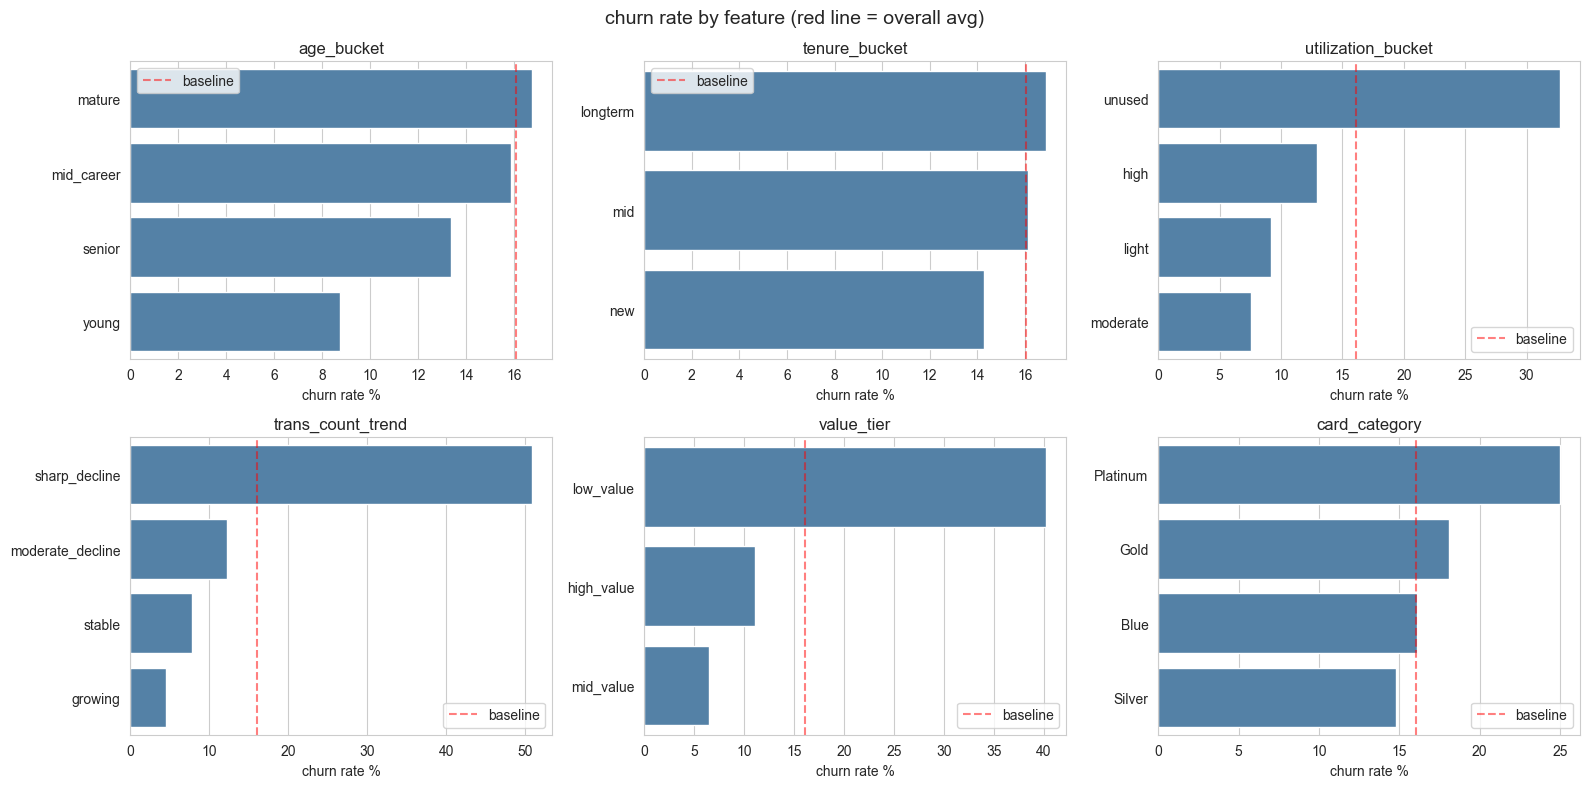

In [3]:
# churn rate by key categorical features
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# pick the features we want to compare
cat_features = ["age_bucket", "tenure_bucket", "utilization_bucket",
                "trans_count_trend", "value_tier", "card_category"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    # group by feature, get churn rate
    churn_by_feature = df.groupby(feature)["churn"].mean().sort_values(ascending=False)

    sns.barplot(x=churn_by_feature.values * 100,
                y=churn_by_feature.index,
                ax=axes[i],
                color="steelblue")
    axes[i].set_xlabel("churn rate %")
    axes[i].set_ylabel("")
    axes[i].set_title(feature)
    axes[i].axvline(churn_rate * 100, color="red", linestyle="--", alpha=0.5, label="baseline")
    axes[i].legend()

plt.suptitle("churn rate by feature (red line = overall avg)", fontsize=14)
plt.tight_layout()
plt.show()

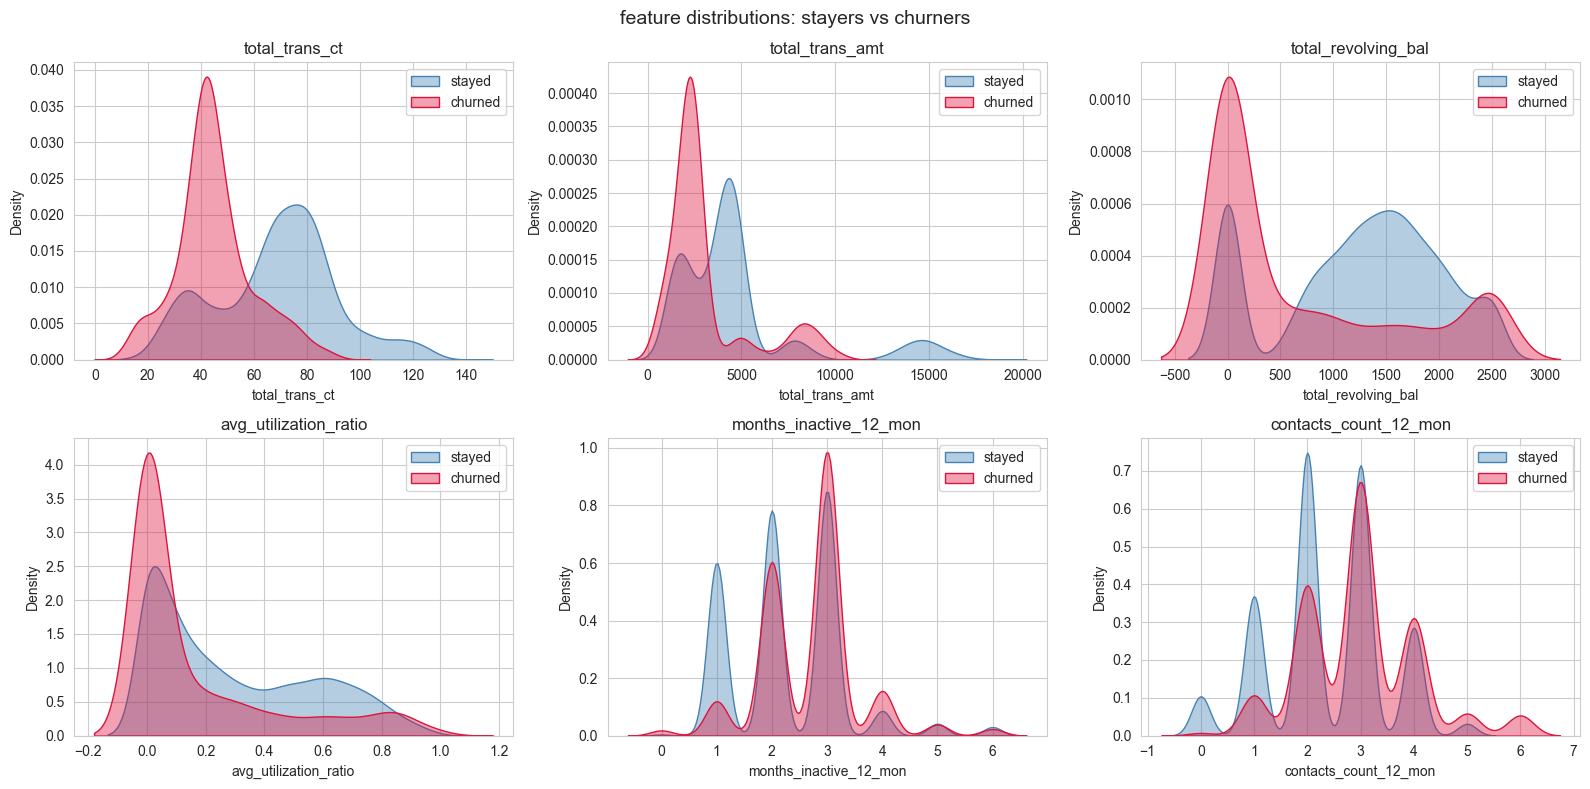

In [4]:
# distributions of key numeric features, split by churn status

numeric_features = ["total_trans_ct", "total_trans_amt",
                    "total_revolving_bal", "avg_utilization_ratio",
                    "months_inactive_12_mon", "contacts_count_12_mon"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    # plot stayers (churn=0) and churners (churn=1) on the same axis
    sns.kdeplot(data=df[df["churn"] == 0], x=feature, ax=axes[i],
                label="stayed", fill=True, alpha=0.4, color="steelblue")
    sns.kdeplot(data=df[df["churn"] == 1], x=feature, ax=axes[i],
                label="churned", fill=True, alpha=0.4, color="crimson")
    axes[i].set_title(feature)
    axes[i].legend()

plt.suptitle("feature distributions: stayers vs churners", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# data prep for modeling
from sklearn.model_selection import train_test_split

# features the model is NOT allowed to see
# (these are for business segmentation, not prediction)
segmentation_cols = ["est_annual_revenue", "revenue_percentile",
                     "credit_limit_percentile", "value_tier", "is_premium_card"]

# build X (features) and y (target)
y = df["churn"]
X = df.drop(columns=["churn"] + segmentation_cols)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"churn rate in full data: {y.mean():.2%}")

X shape: (10127, 27)
y shape: (10127,)
churn rate in full data: 16.07%


In [6]:
# one-hot encode text features
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"before encoding: {X.shape[1]} cols")
print(f"after encoding:  {X_encoded.shape[1]} cols")
print(f"\nfirst few new columns:")
print([c for c in X_encoded.columns if c not in X.columns][:10])

before encoding: 27 cols
after encoding:  47 cols

first few new columns:
['age_bucket_mid_career', 'age_bucket_senior', 'age_bucket_young', 'gender_M', 'education_level_Doctorate', 'education_level_Graduate', 'education_level_High School', 'education_level_Post-Graduate', 'education_level_Uneducated', 'education_level_Unknown']


In [7]:
# split into 80% train, 20% test
# stratify=y keeps the churn rate the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"train: {X_train.shape[0]:,} rows | churn rate: {y_train.mean():.2%}")
print(f"test:  {X_test.shape[0]:,} rows | churn rate: {y_test.mean():.2%}")

train: 8,101 rows | churn rate: 16.07%
test:  2,026 rows | churn rate: 16.04%


In [8]:
from sklearn.preprocessing import StandardScaler

# fit scaler on TRAIN only, then apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("scaling done")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

scaling done
X_train_scaled shape: (8101, 47)


In [9]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' tells the model to weight churners more heavily
# (since they're only 16% of the data, the model would otherwise ignore them)
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)
print("model trained")

model trained


In [10]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# get predictions
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]  # probability of churn

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:")
print(f"  true negatives:  {cm[0,0]:,}  (correctly predicted stay)")
print(f"  false positives: {cm[0,1]:,}  (wrongly flagged as churn)")
print(f"  false negatives: {cm[1,0]:,}  (missed churners)")
print(f"  true positives:  {cm[1,1]:,}  (correctly caught churn)")

# precision, recall, f1
print("\nclassification report:")
print(classification_report(y_test, y_pred, target_names=["stayed", "churned"]))

# roc-auc
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

confusion matrix:
  true negatives:  1,502  (correctly predicted stay)
  false positives: 199  (wrongly flagged as churn)
  false negatives: 44  (missed churners)
  true positives:  281  (correctly caught churn)

classification report:
              precision    recall  f1-score   support

      stayed       0.97      0.88      0.93      1701
     churned       0.59      0.86      0.70       325

    accuracy                           0.88      2026
   macro avg       0.78      0.87      0.81      2026
weighted avg       0.91      0.88      0.89      2026

ROC-AUC: 0.9423


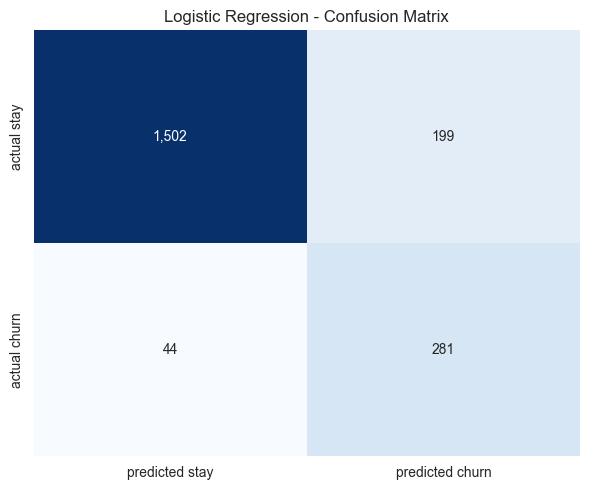

In [11]:
# confusion matrix as a heatmap
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=["predicted stay", "predicted churn"],
    yticklabels=["actual stay", "actual churn"],
    cbar=False,
    ax=ax
)
ax.set_title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

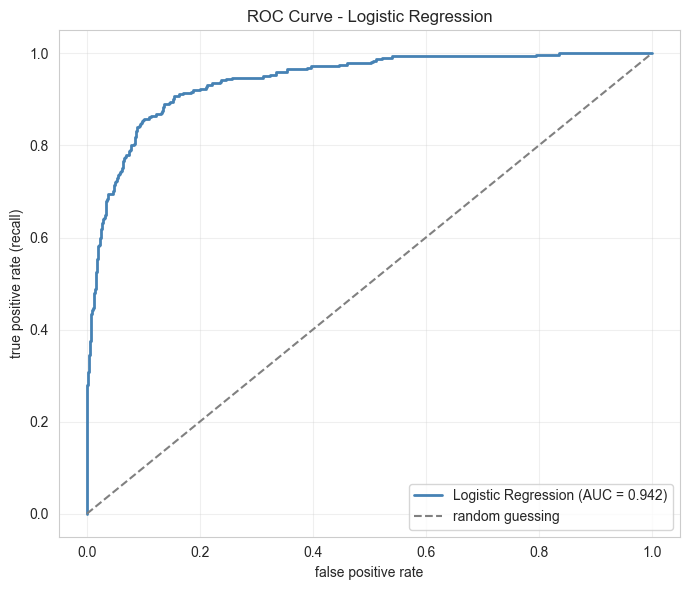

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="random guessing")

ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate (recall)")
ax.set_title("ROC Curve - Logistic Regression")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier

# random forest - no scaling needed for trees
# use UNSCALED features this time
rf = RandomForestClassifier(
    n_estimators=200,            # number of trees in the forest
    max_depth=10,                # max depth of each tree (caps overfitting)
    min_samples_leaf=20,         # each leaf must have at least 20 samples
    class_weight="balanced",     # same imbalance handling as LR
    random_state=42,
    n_jobs=-1                    # use all CPU cores
)

rf.fit(X_train, y_train)
print("random forest trained")

random forest trained


In [14]:
# evaluate random forest
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("confusion matrix:")
print(f"  true negatives:  {cm_rf[0,0]:,}")
print(f"  false positives: {cm_rf[0,1]:,}")
print(f"  false negatives: {cm_rf[1,0]:,}")
print(f"  true positives:  {cm_rf[1,1]:,}")

print("\nclassification report:")
print(classification_report(y_test, y_pred_rf, target_names=["stayed", "churned"]))

auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC: {auc_rf:.4f}")

confusion matrix:
  true negatives:  1,600
  false positives: 101
  false negatives: 35
  true positives:  290

classification report:
              precision    recall  f1-score   support

      stayed       0.98      0.94      0.96      1701
     churned       0.74      0.89      0.81       325

    accuracy                           0.93      2026
   macro avg       0.86      0.92      0.88      2026
weighted avg       0.94      0.93      0.94      2026

ROC-AUC: 0.9772


In [15]:
from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance for xgboost
# rule of thumb: ratio of negatives to positives in training data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

xgb = XGBClassifier(
    n_estimators=300,            # number of trees
    max_depth=6,                 # shallow trees - xgboost prefers this
    learning_rate=0.1,           # how aggressively each tree corrects mistakes
    scale_pos_weight=scale_pos_weight,  # class imbalance fix
    random_state=42,
    eval_metric="logloss",       # what to optimize during training
    n_jobs=-1
)

xgb.fit(X_train, y_train)
print("xgboost trained")
print(f"used scale_pos_weight = {scale_pos_weight:.2f}")

xgboost trained
used scale_pos_weight = 5.22


In [16]:
# evaluate xgboost
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("confusion matrix:")
print(f"  true negatives:  {cm_xgb[0,0]:,}")
print(f"  false positives: {cm_xgb[0,1]:,}")
print(f"  false negatives: {cm_xgb[1,0]:,}")
print(f"  true positives:  {cm_xgb[1,1]:,}")

print("\nclassification report:")
print(classification_report(y_test, y_pred_xgb, target_names=["stayed", "churned"]))

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC: {auc_xgb:.4f}")

confusion matrix:
  true negatives:  1,668
  false positives: 33
  false negatives: 22
  true positives:  303

classification report:
              precision    recall  f1-score   support

      stayed       0.99      0.98      0.98      1701
     churned       0.90      0.93      0.92       325

    accuracy                           0.97      2026
   macro avg       0.94      0.96      0.95      2026
weighted avg       0.97      0.97      0.97      2026

ROC-AUC: 0.9927


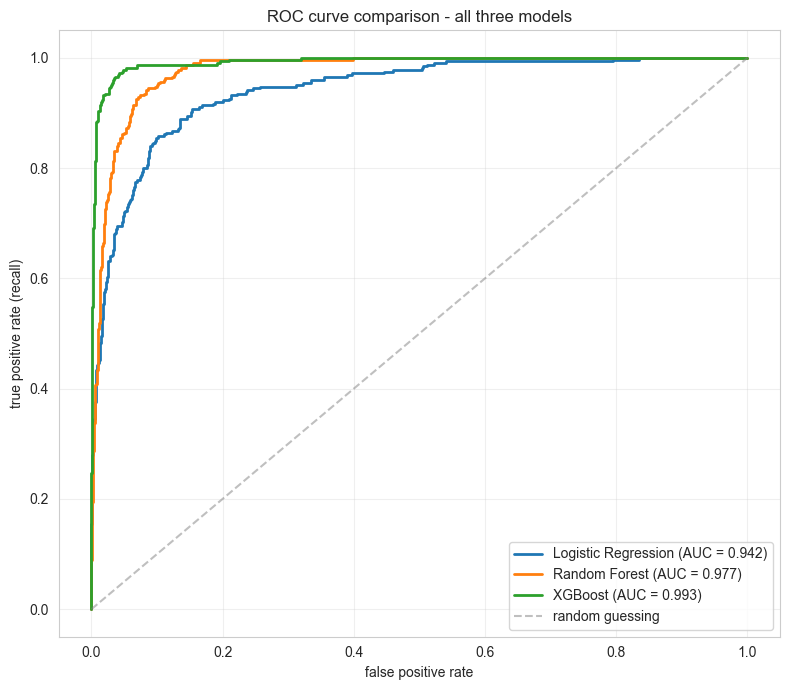

In [17]:
# all three roc curves on one chart
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr_lr, tpr_lr, linewidth=2, label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot(fpr_rf, tpr_rf, linewidth=2, label=f"Random Forest (AUC = {auc_rf:.3f})")
ax.plot(fpr_xgb, tpr_xgb, linewidth=2, label=f"XGBoost (AUC = {auc_xgb:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.5, label="random guessing")

ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate (recall)")
ax.set_title("ROC curve comparison - all three models")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# build comparison table
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "roc_auc": [auc, auc_rf, auc_xgb],
    "churn_precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
    ],
    "churn_recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
    ],
    "churn_f1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
    ],
})

results = results.round(4)
print(results.to_string(index=False))

              model  roc_auc  churn_precision  churn_recall  churn_f1
Logistic Regression   0.9423           0.5854        0.8646    0.6981
      Random Forest   0.9772           0.7417        0.8923    0.8101
            XGBoost   0.9927           0.9018        0.9323    0.9168


In [19]:
import shap

# create shap explainer for xgboost
explainer = shap.TreeExplainer(xgb)

# compute shap values for the test set
shap_values = explainer.shap_values(X_test)

print(f"shap values shape: {shap_values.shape}")
print(f"(rows = test customers, cols = features)")

shap values shape: (2026, 47)
(rows = test customers, cols = features)


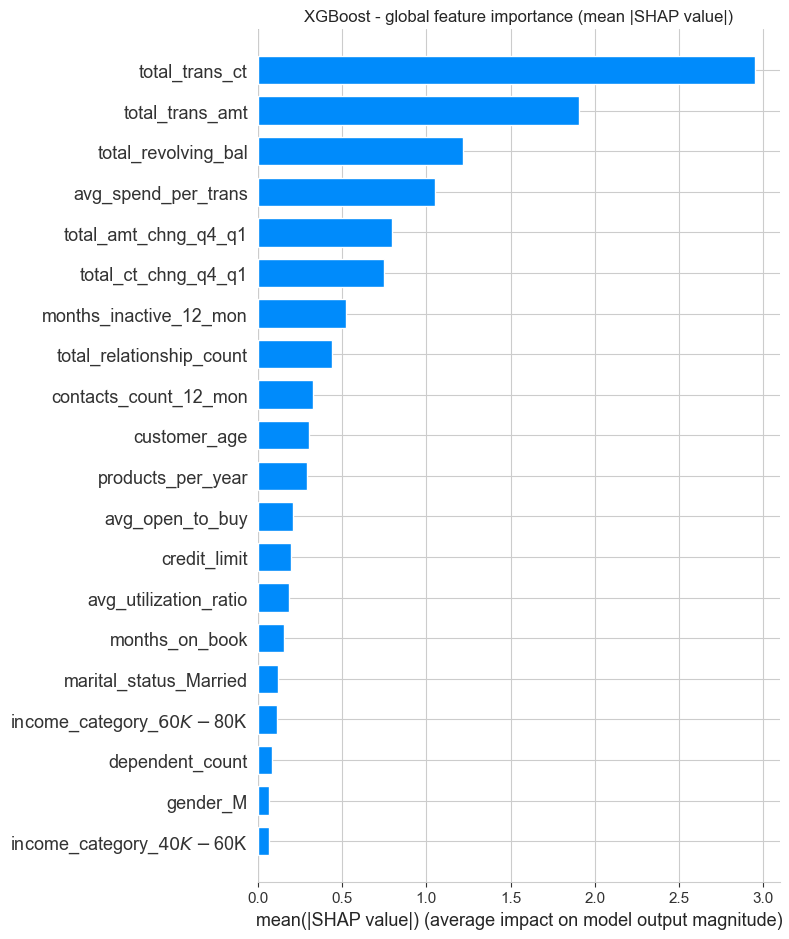

In [20]:
# global feature importance - which features matter most overall
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("XGBoost - global feature importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()


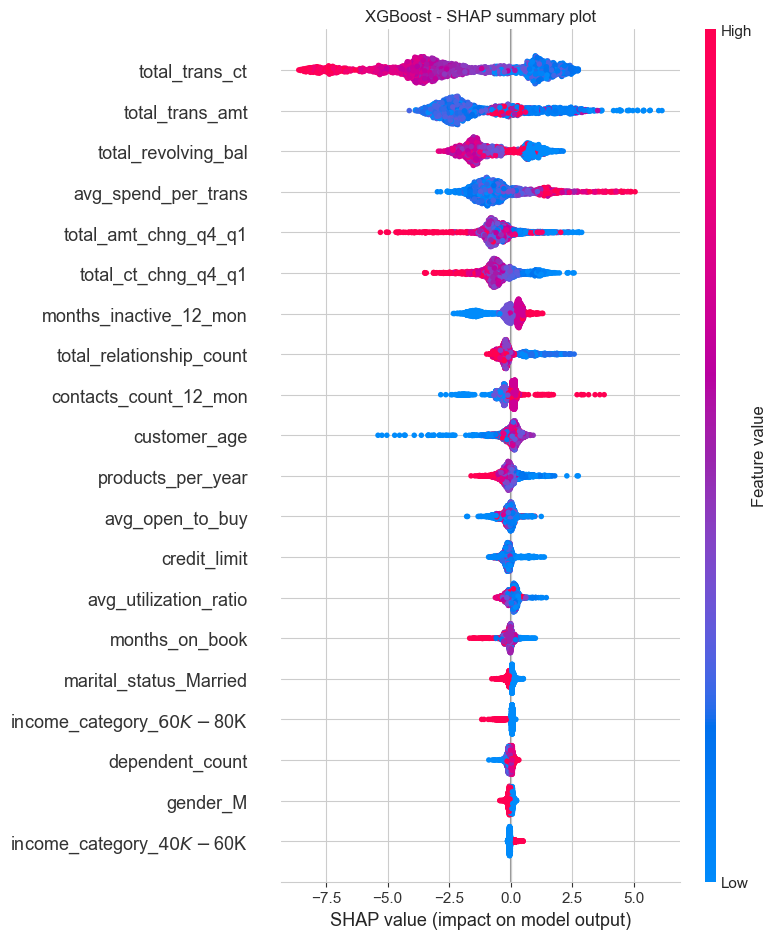

In [21]:
# beeswarm summary plot - shows feature impact AND direction
shap.summary_plot(shap_values, X_test, show=False)
plt.title("XGBoost - SHAP summary plot")
plt.tight_layout()
plt.show()

In [22]:
# find the customer the model is MOST confident is churning
# (highest predicted probability)
most_likely_churner_idx = y_proba_xgb.argmax()

# get their details
customer_features = X_test.iloc[most_likely_churner_idx]
predicted_prob = y_proba_xgb[most_likely_churner_idx]
actual_label = y_test.iloc[most_likely_churner_idx]

print(f"customer index: {most_likely_churner_idx}")
print(f"predicted churn probability: {predicted_prob:.2%}")
print(f"actual outcome: {'churned' if actual_label == 1 else 'stayed'}")
print(f"\nkey features for this customer:")
print(f"  total_trans_ct:           {customer_features['total_trans_ct']:.0f}")
print(f"  total_trans_amt:          ${customer_features['total_trans_amt']:.0f}")
print(f"  total_revolving_bal:      ${customer_features['total_revolving_bal']:.0f}")
print(f"  months_inactive_12_mon:   {customer_features['months_inactive_12_mon']:.0f}")
print(f"  contacts_count_12_mon:    {customer_features['contacts_count_12_mon']:.0f}")
print(f"  customer_age:             {customer_features['customer_age']:.0f}")

customer index: 1414
predicted churn probability: 100.00%
actual outcome: churned

key features for this customer:
  total_trans_ct:           44
  total_trans_amt:          $2273
  total_revolving_bal:      $0
  months_inactive_12_mon:   3
  contacts_count_12_mon:    3
  customer_age:             42


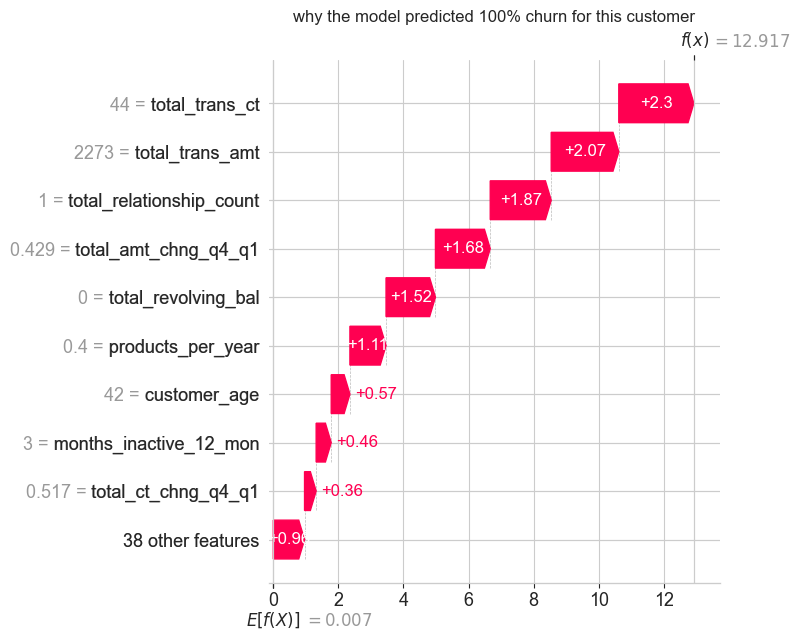

In [23]:
# waterfall plot - shows exactly how this prediction was built up
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[most_likely_churner_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[most_likely_churner_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title(f"why the model predicted {predicted_prob:.0%} churn for this customer")
plt.tight_layout()
plt.show()

In [24]:
# business assumptions
retention_offer_cost = 25       # cost of sending one retention offer
avg_lifetime_value = 800        # avg LTV of a retained customer
retention_offer_success_rate = 0.40  # 40% of accepted offers prevent churn

# expected value of a retention offer if customer is actually going to churn
# (save them with 40% probability, capturing their LTV)
ev_save_a_churner = retention_offer_success_rate * avg_lifetime_value
print(f"expected value of saving a churner: ${ev_save_a_churner:.0f}")
print(f"cost of a wasted offer (false positive): ${retention_offer_cost}")
print(f"break-even ratio: {ev_save_a_churner / retention_offer_cost:.1f}x")

expected value of saving a churner: $320
cost of a wasted offer (false positive): $25
break-even ratio: 12.8x


In [25]:
# sweep through every threshold and compute expected profit
import numpy as np

# use xgboost probabilities (our best model)
thresholds = np.linspace(0.01, 0.99, 99)

profits = []
recalls = []
precisions = []
n_flagged = []

for thresh in thresholds:
    # predict churn at this threshold
    preds = (y_proba_xgb >= thresh).astype(int)

    # confusion matrix components
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()

    # profit calculation:
    # true positive -> we sent offer, saved 40% of the time -> +$320 EV per save attempt
    # but the offer itself cost $25 for everyone we contacted
    revenue = tp * ev_save_a_churner
    offer_cost = (tp + fp) * retention_offer_cost
    profit = revenue - offer_cost

    profits.append(profit)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
    n_flagged.append(tp + fp)

# find the best threshold
best_idx = np.argmax(profits)
best_thresh = thresholds[best_idx]
best_profit = profits[best_idx]

print(f"optimal threshold: {best_thresh:.2f}")
print(f"expected profit at optimum: ${best_profit:,.0f}")
print(f"recall at optimum: {recalls[best_idx]:.2%}")
print(f"precision at optimum: {precisions[best_idx]:.2%}")
print(f"customers flagged: {n_flagged[best_idx]:,}")
print(f"")
print(f"comparison - default 0.5 threshold:")
idx_05 = np.argmin(np.abs(thresholds - 0.5))
print(f"  profit at 0.5: ${profits[idx_05]:,.0f}")
print(f"  recall at 0.5: {recalls[idx_05]:.2%}")
print(f"  precision at 0.5: {precisions[idx_05]:.2%}")

optimal threshold: 0.08
expected profit at optimum: $91,755
recall at optimum: 98.15%
precision at optimum: 77.24%
customers flagged: 413

comparison - default 0.5 threshold:
  profit at 0.5: $88,560
  recall at 0.5: 93.23%
  precision at 0.5: 90.18%


In [26]:
# build customer segments from model output + business value

# use the optimal threshold we found
HIGH_RISK_THRESHOLD = 0.08

# we need value_tier from the original df, joined back to test customers
# X_test has the original index, so we can pull value_tier from df
test_indices = X_test.index
test_value_tier = df.loc[test_indices, "value_tier"].values
test_revenue = df.loc[test_indices, "est_annual_revenue"].values

# build a segments dataframe
segments_df = pd.DataFrame({
    "churn_prob": y_proba_xgb,
    "actual_churn": y_test.values,
    "value_tier": test_value_tier,
    "est_annual_revenue": test_revenue,
})

# assign risk level
segments_df["risk_level"] = segments_df["churn_prob"].apply(
    lambda p: "high_risk" if p >= HIGH_RISK_THRESHOLD else "low_risk"
)

# define recommended action for each segment
def get_action(row):
    if row["risk_level"] == "high_risk" and row["value_tier"] == "high_value":
        return "priority_call_premium_offer"
    elif row["risk_level"] == "high_risk" and row["value_tier"] == "mid_value":
        return "email_retention_offer"
    elif row["risk_level"] == "high_risk" and row["value_tier"] == "low_value":
        return "basic_email"
    elif row["risk_level"] == "low_risk" and row["value_tier"] == "high_value":
        return "loyalty_rewards_monitor"
    else:
        return "no_action"

segments_df["action"] = segments_df.apply(get_action, axis=1)

# summarize the segments
segment_summary = segments_df.groupby(["risk_level", "value_tier"]).agg(
    n_customers=("churn_prob", "size"),
    avg_churn_prob=("churn_prob", "mean"),
    actual_churn_rate=("actual_churn", "mean"),
    avg_revenue=("est_annual_revenue", "mean"),
).round(3)

print("customer segments (test set):")
print(segment_summary)
print(f"\ntotal customers segmented: {len(segments_df):,}")
print(f"\nrecommended actions distribution:")
print(segments_df["action"].value_counts())

customer segments (test set):
                       n_customers  avg_churn_prob  actual_churn_rate  \
risk_level value_tier                                                   
high_risk  high_value           73           0.755              0.767   
           low_value           230           0.902              0.848   
           mid_value           110           0.699              0.618   
low_risk   high_value          424           0.003              0.005   
           low_value           259           0.004              0.004   
           mid_value           930           0.002              0.003   

                       avg_revenue  
risk_level value_tier               
high_risk  high_value      458.123  
           low_value        35.988  
           mid_value       257.725  
low_risk   high_value      441.931  
           low_value        43.076  
           mid_value       269.201  

total customers segmented: 2,026

recommended actions distribution:
action
no_action    

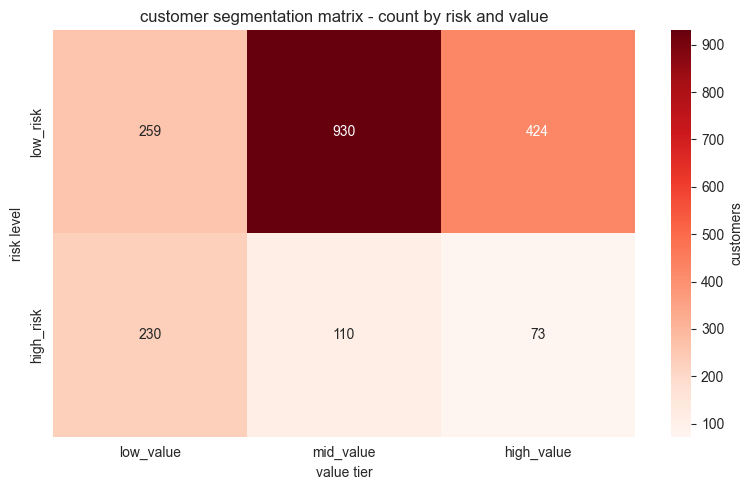

In [27]:
# segmentation matrix visualization

# pivot to a matrix shape
pivot = segments_df.pivot_table(
    index="risk_level",
    columns="value_tier",
    values="actual_churn",
    aggfunc="size"
)

# put cols in sensible order
pivot = pivot[["low_value", "mid_value", "high_value"]]
pivot = pivot.loc[["low_risk", "high_risk"]]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar_kws={"label": "customers"},
    ax=ax
)
ax.set_title("customer segmentation matrix - count by risk and value")
ax.set_xlabel("value tier")
ax.set_ylabel("risk level")
plt.tight_layout()
plt.show()

In [29]:
# save model + scaler + feature cols + shap explainer so the api can load them
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

# not needed for xgb but keeping it in case we swap models later
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# api needs the exact feature order the model was trained on
with open("../models/feature_columns.pkl", "wb") as f:
    pickle.dump(X_encoded.columns.tolist(), f)

with open("../models/shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("saved 4 files to models/")

saved 4 files to models/
